# Sistema de apoyo a la decisión: proveedores por ciudad y tratamiento

Esta versión incorpora el **forecast de demanda para las 50 series seleccionadas previamente** y añade una selección explícita del **umbral de valoración**.

## Flujo
1. Cargar el histórico con `rating_global`.
2. Sustituir ratings ausentes por 3.0.
3. Cargar `forecast_por_serie_H1_H4`.
4. Restringir el análisis a las series `CODIGO_TRATAMIENTO + CODIGO_MUNICIPIO` presentes en el forecast.
5. Construir variables de coste, valoración y capacidad real por combinación.
6. Seleccionar municipio + tratamiento.
7. Seleccionar explícitamente el **umbral de valoración** que se quiere utilizar como escenario principal.
8. Comparar:
   - referencia histórica aplicada a la demanda prevista;
   - índice multicriterio 50/30/20;
   - optimización directa del coste.
9. Mantener una tabla de sensibilidad con 3.5, 3.7, 3.8 y 4.0, **sin elegir automáticamente uno de ellos**.
10. Analizar ahorro agregado, ahorro frente al índice, escenarios inviables y curva ahorro-calidad.

> **Importante:** los cuatro umbrales son escenarios alternativos. El programa no debe tratarlos como si hubiera que escoger automáticamente el menor. El usuario selecciona el umbral principal con el selector.

> **Bases aplicación**: Aparte del análisis, se genera un ranking que nos permitirá asignar los clientes correctamente en una plataforma web.


In [18]:
import numpy as np
import pandas as pd
from scipy.optimize import milp, LinearConstraint, Bounds, differential_evolution
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RUTA_DATOS = "datos_tratamientos_detalle_con_rating_capacidad.xlsx"
RUTA_FORECAST = "forecast_por_serie_H1_H4.xlsx"

UMBRALES_VALORACION = [3.5, 3.7, 3.8, 4.0]
UMBRAL_INICIAL = 3.7

df = pd.read_excel(RUTA_DATOS)
forecast = pd.read_excel(RUTA_FORECAST)

print(f"Histórico: {len(df):,} filas")
print(f"Series del forecast: {len(forecast):,}")
print(f"Valores de CAPACIDAD_ANUAL ausentes: {df['CAPACIDAD_ANUAL'].isna().sum():,}")

Histórico: 72,391 filas
Series del forecast: 50
Valores de CAPACIDAD_ANUAL ausentes: 8


## 1. Valoración real y demanda prevista

In [19]:
n_rating_missing = df["rating_global"].isna().sum()
df["Valoracion"] = df["rating_global"].fillna(3.0)

cols_forecast = [
    "PREDICCION_H1", "PREDICCION_H2",
    "PREDICCION_H3", "PREDICCION_H4"
]
forecast[cols_forecast] = forecast[cols_forecast].apply(pd.to_numeric, errors="coerce").fillna(0)

forecast["DemandaForecast"] = forecast[cols_forecast].sum(axis=1)
forecast_completo = forecast.copy()
demanda_total_forecast = forecast_completo["DemandaForecast"].sum()
# Para la optimización, el volumen esperado se transforma en servicios
# operativos enteros mediante redondeo al servicio entero más cercano. Conservamos el forecast decimal
# original para su interpretación.
forecast["DemandaOperativa"] = np.rint(forecast["DemandaForecast"]).astype(int)
forecast = forecast[forecast["DemandaOperativa"] > 0].copy()

print(f"Ratings ausentes sustituidos por 3.0: {n_rating_missing:,}")
print(f"Series con demanda prevista > 0: {len(forecast):,}")
print(f"Demanda prevista total (50 series): {demanda_total_forecast:,.3f}")

Ratings ausentes sustituidos por 3.0: 25,936
Series con demanda prevista > 0: 45
Demanda prevista total (50 series): 290.197


### Comprobación de la capacidad real

`CAPACIDAD_ANUAL` puede variar entre combinaciones del mismo proveedor. Se comprueba que sea constante dentro de cada combinación `proveedor + municipio + tratamiento`; en los datos utilizados esta condición se cumple. Las combinaciones sin capacidad conocida no forman parte de las series objetivo del forecast.


## 2. Comprobación de la capacidad real

## 3. Selección de las series objetivo

In [20]:
# Una serie objetivo queda definida por tratamiento + municipio.
series_objetivo = forecast[
    ["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO",
     "DESCPROCED", "DESCMUNICIPIO",
     "PREDICCION_H1", "PREDICCION_H2",
     "PREDICCION_H3", "PREDICCION_H4",
     "DemandaForecast", "DemandaOperativa"]
].drop_duplicates()

# El histórico se restringe exclusivamente a esas series.
df_objetivo = df.merge(
    series_objetivo[["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"]],
    left_on=["CODIGO", "CODIGO_MUNICIPIO"],
    right_on=["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"],
    how="inner"
)

print(f"Series objetivo: {len(series_objetivo):,}")
print(f"Tratamientos objetivo: {series_objetivo['CODIGO_TRATAMIENTO'].nunique():,}")
print(f"Municipios objetivo: {series_objetivo['CODIGO_MUNICIPIO'].nunique():,}")
print(f"Registros históricos utilizados: {len(df_objetivo):,}")

Series objetivo: 45
Tratamientos objetivo: 38
Municipios objetivo: 4
Registros históricos utilizados: 7,551


## 4. Tabla de trabajo: municipio + tratamiento + proveedor

In [21]:
modelo = (
    df_objetivo.groupby(
        ["CODIGO_MUNICIPIO", "DESCMUNICIPIO",
         "CODPROVEEDOR", "NOMBREPROVEEDOR",
         "CODIGO", "DESCPROCED"],
        as_index=False
    )
    .agg(
        CosteMedio=("SUMA", "mean"),
        NumCasos=("SUMA", "count"),
        Valoracion=("Valoracion", "mean"),
        CapacidadAnual=("CAPACIDAD_ANUAL", "first")
    )
)

def normalizar_capacidad(grupo):
    minimo, maximo = grupo.min(), grupo.max()

    if np.isclose(minimo, maximo):
        return pd.Series(1.0, index=grupo.index)

    return (grupo - minimo) / (maximo - minimo)

modelo["Capacidad4Semanas"] = (
    modelo["CapacidadAnual"] * 4 / 52
)

modelo["CapacidadNormalizada"] = (
    modelo.groupby(
        ["CODIGO_MUNICIPIO", "CODIGO"]
    )["Capacidad4Semanas"]
    .transform(normalizar_capacidad)
)

def normalizar_coste(grupo):
    minimo, maximo = grupo.min(), grupo.max()
    if np.isclose(minimo, maximo):
        return pd.Series(1.0, index=grupo.index)
    return 1 - (grupo - minimo) / (maximo - minimo)

modelo["CosteNormalizado"] = (
    modelo.groupby(["CODIGO_MUNICIPIO", "CODIGO"])["CosteMedio"]
    .transform(normalizar_coste)
)
modelo["ValoracionNormalizada"] = modelo["Valoracion"] / 5.0

# CAPACIDAD_ANUAL es constante dentro de cada combinación proveedor + municipio + tratamiento.
print(f"Combinaciones ciudad-tratamiento-proveedor: {len(modelo):,}")
print(f"Combinaciones con capacidad anual conocida: {modelo["CapacidadAnual"].notna().sum():,}")
print(f"Combinaciones con capacidad anual ausente: {modelo["CapacidadAnual"].isna().sum():,}")

modelo["Capacidad4Semanas"] = modelo["CapacidadAnual"] * 4 / 52


Combinaciones ciudad-tratamiento-proveedor: 400
Combinaciones con capacidad anual conocida: 400
Combinaciones con capacidad anual ausente: 0


## 5. Selector de ciudad, tratamiento y umbral de valoración

In [22]:
ciudades = (
    series_objetivo[["CODIGO_MUNICIPIO", "DESCMUNICIPIO"]]
    .drop_duplicates()
    .sort_values(["DESCMUNICIPIO", "CODIGO_MUNICIPIO"])
)

def tratamientos_de_ciudad(codigo_municipio):
    return (
        series_objetivo[series_objetivo["CODIGO_MUNICIPIO"] == codigo_municipio]
        [["CODIGO_TRATAMIENTO", "DESCPROCED"]]
        .drop_duplicates()
        .sort_values(["DESCPROCED", "CODIGO_TRATAMIENTO"])
    )

ciudad_inicial = ciudades.iloc[0]["CODIGO_MUNICIPIO"]
tratamientos_iniciales = tratamientos_de_ciudad(ciudad_inicial)

selector_ciudad = widgets.Dropdown(
    options=[(f"{n} - {c}", c) for c, n in ciudades.itertuples(index=False, name=None)],
    value=ciudad_inicial,
    description="Ciudad:",
    layout=widgets.Layout(width="800px")
)

selector_tratamiento = widgets.Dropdown(
    options=[(f"{n} - {c}", c) for c, n in tratamientos_iniciales.itertuples(index=False, name=None)],
    value=tratamientos_iniciales.iloc[0]["CODIGO_TRATAMIENTO"],
    description="Tratamiento:",
    layout=widgets.Layout(width="800px")
)

selector_umbral = widgets.Dropdown(
    options=[(f"{u:.1f}", u) for u in UMBRALES_VALORACION],
    value=UMBRAL_INICIAL,
    description="Valoración mínima:",
    layout=widgets.Layout(width="300px")
)

def actualizar_tratamientos(change):
    tratamientos = tratamientos_de_ciudad(change["new"])
    selector_tratamiento.options = [
        (f"{n} - {c}", c)
        for c, n in tratamientos.itertuples(index=False, name=None)
    ]
    if len(tratamientos):
        selector_tratamiento.value = tratamientos.iloc[0]["CODIGO_TRATAMIENTO"]

selector_ciudad.observe(actualizar_tratamientos, names="value")

display(selector_ciudad)
display(selector_tratamiento)
display(selector_umbral)

Dropdown(description='Ciudad:', layout=Layout(width='800px'), options=(('CHACAO - 015-007-007', '015-007-007')…

Dropdown(description='Tratamiento:', layout=Layout(width='800px'), options=(('MEDICINA INTERNA CONSULTA 1A VEZ…

Dropdown(description='Valoración mínima:', index=1, layout=Layout(width='300px'), options=(('3.5', 3.5), ('3.7…

### ¿Qué significa el selector de umbral?

El programa calcula la sensibilidad para **todos** los umbrales, pero el análisis principal utiliza únicamente el umbral que se seleccione aquí.

Por ejemplo, si se selecciona **3.7**, la pregunta es:

> ¿Cuál es el coste mínimo que podemos alcanzar manteniendo una valoración media de al menos 3.7?

No se selecciona automáticamente 3.5 por producir más ahorro.

## 6. Funciones del modelo

In [23]:
def calcular_indice(
    data,
    peso_coste=0.50,
    peso_valoracion=0.30,
    peso_capacidad=0.20
):

    return (
        peso_coste * data["CosteNormalizado"] +
        peso_valoracion * data["ValoracionNormalizada"] +
        peso_capacidad * data["CapacidadNormalizada"]
    )

def obtener_datos(ciudad, tratamiento):
    datos = modelo[
        (modelo["CODIGO_MUNICIPIO"] == ciudad)
        & (modelo["CODIGO"] == tratamiento)
    ].copy()
    datos = datos.dropna(subset=["CapacidadAnual", "Capacidad4Semanas"]).copy()
    if datos.empty:
        raise ValueError("No existe una serie objetivo con capacidad conocida para la ciudad y tratamiento seleccionados.")
    return datos

def obtener_forecast(ciudad, tratamiento):
    f = forecast[
        (forecast["CODIGO_MUNICIPIO"] == ciudad)
        & (forecast["CODIGO_TRATAMIENTO"] == tratamiento)
    ].copy()
    if f.empty:
        raise ValueError("No existe forecast para esa serie.")
    return f.iloc[0]

def crear_capacidad_maxima(datos):
    """Usa la capacidad real de la combinación y la adapta al horizonte de 4 semanas."""
    datos = datos.copy()
    datos["CapacidadMaxima"] = datos["Capacidad4Semanas"]
    return datos

def demanda_forecast(ciudad, tratamiento):
    f = forecast[
        (forecast["CODIGO_MUNICIPIO"] == ciudad)
        & (forecast["CODIGO_TRATAMIENTO"] == tratamiento)
    ].copy()
    if f.empty:
        raise ValueError("No existe forecast para esa serie.")
    return int(f.iloc[0]["DemandaOperativa"])

def coste_referencia_forecast(datos, demanda):
    coste_medio_historico = np.average(
        datos["CosteMedio"], weights=datos["NumCasos"]
    )
    valoracion_historica = np.average(
        datos["Valoracion"], weights=datos["NumCasos"]
    )
    return {
        "CosteTotal": coste_medio_historico * demanda,
        "ValoracionMedia": valoracion_historica
    }

def asignar_por_indice(datos, demanda, peso_coste=.50, peso_valoracion=.30,
                       peso_capacidad=.20):
    datos = crear_capacidad_maxima(datos)
    datos["Indice"] = calcular_indice(
        datos, peso_coste, peso_valoracion, peso_capacidad
    )
    datos = datos.sort_values(["Indice", "CosteMedio"], ascending=[False, True])

    restantes = int(demanda)
    asignaciones = []

    for _, fila in datos.iterrows():
        if restantes <= 0:
            break
        asignados = min(restantes, int(np.floor(fila["CapacidadMaxima"] + 1e-9)))
        if asignados > 0:
            asignaciones.append({
                "CODPROVEEDOR": fila["CODPROVEEDOR"],
                "NOMBREPROVEEDOR": fila["NOMBREPROVEEDOR"],
                "Servicios": asignados,
                "CosteMedio": fila["CosteMedio"],
                "Valoracion": fila["Valoracion"],
                "CapacidadAnual": fila["CapacidadAnual"],
                "Capacidad4Semanas": fila["Capacidad4Semanas"],
                "Indice": fila["Indice"]
            })
            restantes -= asignados

    asignaciones = pd.DataFrame(asignaciones)
    if asignaciones.empty or restantes > 0:
        return {
            "CosteTotal": np.inf,
            "ValoracionMedia": np.nan,
            "SinAsignar": restantes,
            "Asignaciones": asignaciones
        }

    coste_total = (asignaciones["Servicios"] * asignaciones["CosteMedio"]).sum()
    valoracion_media = np.average(
        asignaciones["Valoracion"], weights=asignaciones["Servicios"]
    )

    return {
        "CosteTotal": coste_total,
        "ValoracionMedia": valoracion_media,
        "SinAsignar": restantes,
        "Asignaciones": asignaciones
    }

def optimizar_coste(datos, demanda, umbral_valoracion):
    datos = crear_capacidad_maxima(datos).reset_index(drop=True)
    n = len(datos)
    demanda = int(demanda)

    costes = datos["CosteMedio"].to_numpy(dtype=float)
    valoraciones = datos["Valoracion"].to_numpy(dtype=float)
    capacidades = np.floor(datos["CapacidadMaxima"].to_numpy(dtype=float) + 1e-9)

    A = np.vstack([np.ones(n), valoraciones])
    lb = np.array([demanda, demanda * umbral_valoracion], dtype=float)
    ub = np.array([demanda, np.inf], dtype=float)

    resultado = milp(
        c=costes,
        integrality=np.ones(n),
        bounds=Bounds(np.zeros(n), capacidades),
        constraints=LinearConstraint(A, lb, ub),
        options={"time_limit": 30}
    )

    if not resultado.success:
        return {
            "Factible": False,
            "Mensaje": resultado.message,
            "CosteTotal": np.nan,
            "ValoracionMedia": np.nan,
            "SinAsignar": demanda,
            "Asignaciones": pd.DataFrame()
        }

    x = np.rint(resultado.x).astype(int)
    coste_total = np.sum(x * costes)
    valoracion_media = np.sum(x * valoraciones) / demanda

    asignaciones = datos.loc[x > 0, [
        "CODPROVEEDOR", "NOMBREPROVEEDOR", "CosteMedio", "Valoracion",
        "CapacidadAnual", "Capacidad4Semanas"
    ]].copy()
    asignaciones["Servicios"] = x[x > 0]
    asignaciones["CosteTotal"] = (
        asignaciones["Servicios"] * asignaciones["CosteMedio"]
    )
    asignaciones = asignaciones.sort_values("Servicios", ascending=False)

    return {
        "Factible": True,
        "Mensaje": resultado.message,
        "CosteTotal": coste_total,
        "ValoracionMedia": valoracion_media,
        "SinAsignar": 0,
        "Asignaciones": asignaciones
    }

def obtener_cuotas_objetivo(
    datos,
    demanda,
    umbral
):

    opt = optimizar_coste(
        datos,
        demanda,
        umbral
    )

    if not opt["Factible"]:
        return pd.DataFrame()

    cuotas = opt["Asignaciones"].copy()

    cuotas["CuotaObjetivo"] = (
        cuotas["Servicios"]
        / cuotas["Servicios"].sum()
    )

    return cuotas[
        [
            "CODPROVEEDOR",
            "NOMBREPROVEEDOR",
            "Servicios",
            "CuotaObjetivo"
        ]
    ]



asignaciones_operativas = {}

def registrar_asignacion(
    proveedor
):

    asignaciones_operativas[
        proveedor
    ] = (
        asignaciones_operativas.get(
            proveedor,
            0
        )
        + 1
    )


def obtener_ranking_operativo(
    ciudad,
    tratamiento,
    umbral
):

    datos = obtener_datos(
        ciudad,
        tratamiento
    ).copy()

    demanda = demanda_forecast(
        ciudad,
        tratamiento
    )

    cuotas_objetivo = (
        obtener_cuotas_objetivo(
            datos,
            demanda,
            umbral
        )
    )

    if cuotas_objetivo.empty:
        return pd.DataFrame()

    datos = datos.merge(
        cuotas_objetivo[
            [
                "CODPROVEEDOR",
                "CuotaObjetivo"
            ]
        ],
        on="CODPROVEEDOR",
        how="inner"
    )

    total_real = sum(
        asignaciones_operativas.values()
    )

    datos["CuotaReal"] = datos[
        "CODPROVEEDOR"
    ].map(
        lambda x:
        asignaciones_operativas.get(x, 0)
        / max(total_real, 1)
    )

    datos["DesviacionPlan"] = (
        datos["CuotaObjetivo"]
        - datos["CuotaReal"]
    )

    datos["ScoreDesviacion"] = (
        datos["DesviacionPlan"]
        - datos["DesviacionPlan"].min()
    )

    if (
        datos["ScoreDesviacion"].max()
        > 0
    ):
        datos["ScoreDesviacion"] /= (
            datos["ScoreDesviacion"].max()
        )

    datos["RankingOperativo"] = (
        0.50
        * datos["CosteNormalizado"]
        + 0.30
        * datos["ValoracionNormalizada"]
        + 0.20
        * datos["ScoreDesviacion"]
    )

    return (
        datos.sort_values(
            "RankingOperativo",
            ascending=False
        )
        [
            [
                "CODPROVEEDOR",
                "NOMBREPROVEEDOR",
                "CosteMedio",
                "Valoracion",
                "CuotaObjetivo",
                "CuotaReal",
                "RankingOperativo"
            ]
        ]
    )


def analizar_umbrales(datos, demanda, umbrales=UMBRALES_VALORACION):
    referencia = coste_referencia_forecast(datos, demanda)
    base = asignar_por_indice(datos, demanda, .50, .30, .20)
    filas = []

    for umbral in umbrales:
        opt = optimizar_coste(datos, demanda, umbral)

        if opt["Factible"]:
            ahorro_ref = referencia["CosteTotal"] - opt["CosteTotal"]
            ahorro_indice = base["CosteTotal"] - opt["CosteTotal"]
            ahorro_ref_pct = 100 * ahorro_ref / referencia["CosteTotal"]
            ahorro_indice_pct = 100 * ahorro_indice / base["CosteTotal"]
            motivo = "Factible"
        else:
            ahorro_ref = ahorro_indice = np.nan
            ahorro_ref_pct = ahorro_indice_pct = np.nan
            motivo = "No factible"

        filas.append({
            "UmbralValoracion": umbral,
            "Factible": opt["Factible"],
            "Motivo": motivo,
            "CosteReferenciaForecast": referencia["CosteTotal"],
            "CosteIndiceBase": base["CosteTotal"],
            "CosteOptimizado": opt["CosteTotal"],
            "AhorroVsReferencia": ahorro_ref,
            "AhorroPctVsReferencia": ahorro_ref_pct,
            "AhorroVsIndice": ahorro_indice,
            "AhorroPctVsIndice": ahorro_indice_pct,
            "ValoracionOptimizada": opt["ValoracionMedia"],
            "SinAsignar": opt["SinAsignar"]
        })

    return pd.DataFrame(filas)


def obtener_ranking_web(
    ciudad,
    tratamiento,
    umbral,
    cuotas_objetivo=None
):

    datos = obtener_datos(
        ciudad,
        tratamiento
    ).copy()

    datos = crear_capacidad_maxima(datos)

    # filtro de calidad
    datos = datos[
        datos["Valoracion"] >= umbral
    ].copy()

    # filtro de capacidad
    datos = datos[
        datos["CapacidadMaxima"] > 0
    ].copy()

    if datos.empty:
        return pd.DataFrame()

    # Si existen cuotas objetivo del MILP
    if cuotas_objetivo is not None:

        datos = datos.merge(
            cuotas_objetivo[
                [
                    "CODPROVEEDOR",
                    "CuotaObjetivo"
                ]
            ],
            on="CODPROVEEDOR",
            how="left"
        )

    else:

        datos["CuotaObjetivo"] = np.nan

    # Ranking operativo
    datos["RankingWeb"] = (
        0.60 * datos["CosteNormalizado"]
        +
        0.40 * datos["ValoracionNormalizada"]
    )

    datos = datos.sort_values(
        "RankingWeb",
        ascending=False
    )

    return datos[
        [
            "CODPROVEEDOR",
            "NOMBREPROVEEDOR",
            "CosteMedio",
            "Valoracion",
            "Capacidad4Semanas",
            "CuotaObjetivo",
            "RankingWeb"
        ]
    ]

## 6. Resultado de la serie seleccionada

In [24]:
CIUDAD_SELECCIONADA = selector_ciudad.value
TRATAMIENTO_SELECCIONADO = selector_tratamiento.value
UMBRAL_SELECCIONADO = float(selector_umbral.value)

datos_seleccion = obtener_datos(CIUDAD_SELECCIONADA, TRATAMIENTO_SELECCIONADO)
forecast_seleccion = obtener_forecast(CIUDAD_SELECCIONADA, TRATAMIENTO_SELECCIONADO)
DEMANDA = demanda_forecast(CIUDAD_SELECCIONADA, TRATAMIENTO_SELECCIONADO)

referencia = coste_referencia_forecast(datos_seleccion, DEMANDA)
base = asignar_por_indice(datos_seleccion, DEMANDA, .50, .30, .20)
sensibilidad = analizar_umbrales(datos_seleccion, DEMANDA)

escenario = sensibilidad[
    np.isclose(sensibilidad["UmbralValoracion"], UMBRAL_SELECCIONADO)
].iloc[0]

print(f"Ciudad: {datos_seleccion['DESCMUNICIPIO'].iloc[0]}")
print(f"Tratamiento: {datos_seleccion['DESCPROCED'].iloc[0]}")
print(f"Demanda prevista (forecast): {forecast_seleccion['DemandaForecast']:,.3f}")
print(f"Demanda operativa utilizada: {DEMANDA:,}")
print(f"Forecast H1-H4: {np.round(forecast_seleccion[cols_forecast],3)}")
print(f"Umbral seleccionado: {UMBRAL_SELECCIONADO:.1f}")
print(f"Coste referencia: {referencia['CosteTotal']:,.2f} €")
print(f"Coste índice 50/30/20: {base['CosteTotal']:,.2f} €")
print(f"Coste optimizado: {escenario['CosteOptimizado']:,.2f} €")
print(f"Ahorro vs referencia: {escenario['AhorroVsReferencia']:,.2f} € ({escenario['AhorroPctVsReferencia']:.2f}%)")
print(f"Ahorro adicional vs índice: {escenario['AhorroVsIndice']:,.2f} € ({escenario['AhorroPctVsIndice']:.2f}%)")
print(f"Valoración optimizada: {escenario['ValoracionOptimizada']:.3f}")

Ciudad: CHACAO
Tratamiento: MEDICINA INTERNA CONSULTA 1A VEZ
Demanda prevista (forecast): 9.059
Demanda operativa utilizada: 9
Forecast H1-H4: PREDICCION_H1   2.107
PREDICCION_H2   1.964
PREDICCION_H3   2.113
PREDICCION_H4   2.875
Name: 6, dtype: object
Umbral seleccionado: 3.7
Coste referencia: 225.91 €
Coste índice 50/30/20: 225.00 €
Coste optimizado: 225.00 €
Ahorro vs referencia: 0.91 € (0.40%)
Ahorro adicional vs índice: 0.00 € (0.00%)
Valoración optimizada: 4.244


## 7. Sensibilidad: todos los umbrales, sin selección automática

In [25]:
sensibilidad.round(3)

,UmbralValoracion,Factible,Motivo,CosteReferenciaForecast,CosteIndiceBase,CosteOptimizado,AhorroVsReferencia,AhorroPctVsReferencia,AhorroVsIndice,AhorroPctVsIndice,ValoracionOptimizada,SinAsignar
0,3.500,True,Factible,225.915,225.000,225.000,0.915,0.405,0.000,0.000,4.244,0
1,3.700,True,Factible,225.915,225.000,225.000,0.915,0.405,0.000,0.000,4.244,0
2,3.800,True,Factible,225.915,225.000,225.000,0.915,0.405,0.000,0.000,4.244,0
3,4.000,True,Factible,225.915,225.000,225.000,0.915,0.405,0.000,0.000,4.244,0


## 8. Asignación de proveedores para el umbral seleccionado

In [26]:
optimo_seleccionado = optimizar_coste(
    datos_seleccion,
    DEMANDA,
    UMBRAL_SELECCIONADO
)

if optimo_seleccionado["Factible"]:
    display(optimo_seleccionado["Asignaciones"].round(3))
else:
    print(optimo_seleccionado["Mensaje"])

cuotas_objetivo = optimo_seleccionado["Asignaciones"].copy()

if not cuotas_objetivo.empty:

    cuotas_objetivo["CuotaObjetivo"] = (
        cuotas_objetivo["Servicios"]
        / cuotas_objetivo["Servicios"].sum()
    )

display(
    cuotas_objetivo[
        [
            "CODPROVEEDOR",
            "NOMBREPROVEEDOR",
            "Servicios",
            "CuotaObjetivo"
        ]
    ]
)

,CODPROVEEDOR,NOMBREPROVEEDOR,CosteMedio,Valoracion,CapacidadAnual,Capacidad4Semanas,Servicios,CosteTotal
4,33416,GMAX CLINIC C.A.,25.000,5.000,70.000,5.385,5,125.000
3,32196,CLINICAS SOLUMEDICA C.A,25.000,3.000,50.000,3.846,3,75.000
6,34276,FLIGHT CENTER INTL AVIATION GROUP C.A.,25.000,4.200,20.000,1.538,1,25.000


,CODPROVEEDOR,NOMBREPROVEEDOR,Servicios,CuotaObjetivo
4,33416,GMAX CLINIC C.A.,5,0.556
3,32196,CLINICAS SOLUMEDICA C.A,3,0.333
6,34276,FLIGHT CENTER INTL AVIATION GROUP C.A.,1,0.111


## 8B. Ranking operativo para la web

In [27]:
ranking_operativo = obtener_ranking_operativo(
    CIUDAD_SELECCIONADA,
    TRATAMIENTO_SELECCIONADO,
    UMBRAL_SELECCIONADO
)

display(ranking_operativo.round(3))

,CODPROVEEDOR,NOMBREPROVEEDOR,CosteMedio,Valoracion,CuotaObjetivo,CuotaReal,RankingOperativo
1,33416,GMAX CLINIC C.A.,25.000,5.000,0.556,0.000,1.000
0,32196,CLINICAS SOLUMEDICA C.A,25.000,3.000,0.333,0.000,0.780
2,34276,FLIGHT CENTER INTL AVIATION GROUP C.A.,25.000,4.200,0.111,0.000,0.752


## 8B. Ranking para aplicación web


In [28]:
cuotas_objetivo = (
    optimo_seleccionado["Asignaciones"]
    .copy()
)

if not cuotas_objetivo.empty:

    cuotas_objetivo["CuotaObjetivo"] = (
        cuotas_objetivo["Servicios"]
        /
        cuotas_objetivo["Servicios"].sum()
    )

ranking_web = obtener_ranking_web(
    CIUDAD_SELECCIONADA,
    TRATAMIENTO_SELECCIONADO,
    UMBRAL_SELECCIONADO,
    cuotas_objetivo
)

display(
    ranking_web.round(3)
)

,CODPROVEEDOR,NOMBREPROVEEDOR,CosteMedio,Valoracion,Capacidad4Semanas,CuotaObjetivo,RankingWeb
2,33416,GMAX CLINIC C.A.,25.000,5.000,5.385,0.556,1.000
1,32096,JUAN CARLOS VARGAS,25.000,4.400,1.538,NaN,0.952
4,34276,FLIGHT CENTER INTL AVIATION GROUP C.A.,25.000,4.200,1.538,0.111,0.936
3,34156,RENACER SALUD C.A,25.000,4.000,1.538,NaN,0.920
0,10951,RAMON RAMON FUENMAYOR FUENMAYOR,27.500,4.000,1.538,NaN,0.320


## 9. Validación sobre todas las series objetivo

In [29]:
resultados = []

for _, serie in series_objetivo.iterrows():
    ciudad = serie["CODIGO_MUNICIPIO"]
    tratamiento = serie["CODIGO_TRATAMIENTO"]
    datos_t = obtener_datos(ciudad, tratamiento)
    demanda_t = int(serie["DemandaOperativa"])

    referencia_t = coste_referencia_forecast(datos_t, demanda_t)
    base_t = asignar_por_indice(datos_t, demanda_t, .50, .30, .20)

    for umbral in UMBRALES_VALORACION:
        opt_t = optimizar_coste(datos_t, demanda_t, umbral)

        if opt_t["Factible"]:
            motivo = "Factible"
            ahorro_ref = referencia_t["CosteTotal"] - opt_t["CosteTotal"]
            ahorro_indice = base_t["CosteTotal"] - opt_t["CosteTotal"]
            ahorro_ref_pct = 100 * ahorro_ref / referencia_t["CosteTotal"]
            ahorro_indice_pct = 100 * ahorro_indice / base_t["CosteTotal"]
        else:
            motivo = "No factible"
            ahorro_ref = ahorro_indice = np.nan
            ahorro_ref_pct = ahorro_indice_pct = np.nan

        resultados.append({
            "Ciudad": serie["DESCMUNICIPIO"],
            "CODIGO_MUNICIPIO": ciudad,
            "Tratamiento": serie["DESCPROCED"],
            "CODIGO": tratamiento,
            "NProveedores": len(datos_t),
            "DemandaForecast": float(serie["DemandaForecast"]),
            "DemandaOperativa": demanda_t,
            "UmbralValoracion": umbral,
            "Factible": opt_t["Factible"],
            "Motivo": motivo,
            "CosteReferenciaForecast": referencia_t["CosteTotal"],
            "CosteIndiceBase": base_t["CosteTotal"],
            "CosteOptimizado": opt_t["CosteTotal"],
            "AhorroVsReferencia": ahorro_ref,
            "AhorroPctVsReferencia": ahorro_ref_pct,
            "AhorroVsIndice": ahorro_indice,
            "AhorroPctVsIndice": ahorro_indice_pct,
            "ValoracionOptimizada": opt_t["ValoracionMedia"]
        })

resultados_validacion = pd.DataFrame(resultados)
print(f"Escenarios evaluados: {len(resultados_validacion):,}")

Escenarios evaluados: 180


## 10. Ranking de ahorro para el umbral seleccionado

In [30]:
ranking_ahorro = (
    resultados_validacion[
        (resultados_validacion["Factible"])
        & (np.isclose(resultados_validacion["UmbralValoracion"], UMBRAL_SELECCIONADO))
    ]
    .sort_values("AhorroVsReferencia", ascending=False)
    [[
        "Ciudad", "CODIGO_MUNICIPIO", "Tratamiento", "CODIGO",
        "NProveedores", "DemandaForecast", "UmbralValoracion",
        "CosteReferenciaForecast", "CosteIndiceBase",
        "CosteOptimizado", "AhorroVsReferencia",
        "AhorroPctVsReferencia", "AhorroVsIndice",
        "AhorroPctVsIndice", "ValoracionOptimizada"
    ]]
)

ranking_ahorro.head(20).round(3)

,Ciudad,CODIGO_MUNICIPIO,Tratamiento,CODIGO,NProveedores,DemandaForecast,UmbralValoracion,CosteReferenciaForecast,CosteIndiceBase,CosteOptimizado,AhorroVsReferencia,AhorroPctVsReferencia,AhorroVsIndice,AhorroPctVsIndice,ValoracionOptimizada
173,LIBERTADOR,001-002-004,SERVICIO DE HABITACION PRIVADA: SERVICIOS DE H...,602000010,10,2.419,3.700,774.369,449.760,317.174,457.195,59.041,132.586,29.479,3.900
177,LIBERTADOR,001-002-004,USO DE QUIROFANO POR HORA: PERSONAL FIJO DEL Á...,603000017,13,2.397,3.700,"1,311.508","1,119.097",986.977,324.532,24.745,132.120,11.806,3.750
165,LIBERTADOR,001-002-004,BIOPSIA (ANATOMIA PATOLOGICA),404010001,10,0.548,3.700,200.212,60.000,60.000,140.212,70.032,0.000,0.000,4.000
105,LIBERTADOR,001-002-004,LABORATORIO GENERAL (SOLO PARA CARTA AVAL / RE...,401200051,10,2.173,3.700,206.034,102.577,96.133,109.901,53.341,6.443,6.281,3.750
117,LIBERTADOR,001-002-004,ECOGRAFIA DE MAMA,402010015,7,2.293,3.700,130.377,60.000,60.000,70.377,53.980,0.000,0.000,3.850
169,LIBERTADOR,001-002-004,REHABILITACION INTEGRAL 10 SESIONES,501000062,7,2.459,3.700,467.683,412.903,400.000,67.683,14.472,12.903,3.125,3.800
81,LIBERTADOR,001-002-004,ANESTESIOLOGIA VALORACION PREANESTESICA,120010009,7,1.621,3.700,124.381,115.208,70.000,54.381,43.721,45.208,39.240,4.100
137,LIBERTADOR,001-002-004,RX TORAX 2 PROYECCIONES,402030526,11,4.697,3.700,148.923,105.000,96.000,52.923,35.537,9.000,8.571,3.920
33,LIBERTADOR,001-002-004,EVALUACION CARDIOVASCULAR PREOPERATORIA MEDICI...,109010009,8,2.108,3.700,132.576,120.000,85.000,47.576,35.886,35.000,29.167,3.900
37,LIBERTADOR,001-002-004,CARDIOLOGIA CONSULTA 1A VEZ + ELECTROCARDIOGRAMA,109020001,8,19.640,3.700,849.529,804.745,804.035,45.494,5.355,0.710,0.088,3.965


## 11. Resumen agregado para el umbral seleccionado

In [31]:
agg = resultados_validacion[
    (resultados_validacion["Factible"])
    & (np.isclose(resultados_validacion["UmbralValoracion"], UMBRAL_SELECCIONADO))
].copy()

no_factibles = resultados_validacion[
    (np.isclose(resultados_validacion["UmbralValoracion"], UMBRAL_SELECCIONADO))
    & (~resultados_validacion["Factible"])
].copy()

if agg.empty:
    print("No hay escenarios factibles para el umbral seleccionado.")
else:
    coste_ref_total = agg["CosteReferenciaForecast"].sum()
    coste_indice_total = agg["CosteIndiceBase"].sum()
    coste_opt_total = agg["CosteOptimizado"].sum()

    ahorro_total_ref = coste_ref_total - coste_opt_total
    ahorro_total_indice = coste_indice_total - coste_opt_total

    print(f"Umbral seleccionado: {UMBRAL_SELECCIONADO:.1f}")
    print(f"Escenarios factibles: {len(agg):,}")
    print(f"Escenarios no factibles: {len(no_factibles):,}")
    print(f"Coste referencia total: {coste_ref_total:,.2f} €")
    print(f"Coste índice total: {coste_indice_total:,.2f} €")
    print(f"Coste optimizado total: {coste_opt_total:,.2f} €")
    print(f"Ahorro total vs referencia: {ahorro_total_ref:,.2f} €")
    print(f"Ahorro % total vs referencia: {100 * ahorro_total_ref / coste_ref_total:.2f}%")
    print(f"Ahorro adicional vs índice: {ahorro_total_indice:,.2f} €")
    print(f"Ahorro % adicional vs índice: {100 * ahorro_total_indice / coste_indice_total:.2f}%")
    print(f"Ahorro medio por escenario: {agg['AhorroVsReferencia'].mean():,.2f} €")

    valoracion_media_global = np.average(
    agg["ValoracionOptimizada"],
    weights=agg["DemandaOperativa"]
)

print(
    f"Valoración media global optimizada: "
    f"{valoracion_media_global:.3f}"
)

print(
    f"Valoración mínima alcanzada: "
    f"{agg['ValoracionOptimizada'].min():.3f}"
)

Umbral seleccionado: 3.7
Escenarios factibles: 43
Escenarios no factibles: 2
Coste referencia total: 10,892.84 €
Coste índice total: 9,494.87 €
Coste optimizado total: 9,215.74 €
Ahorro total vs referencia: 1,677.09 €
Ahorro % total vs referencia: 15.40%
Ahorro adicional vs índice: 279.13 €
Ahorro % adicional vs índice: 2.94%
Ahorro medio por escenario: 39.00 €
Valoración media global optimizada: 3.823
Valoración mínima alcanzada: 3.700


## 12. Diagnóstico de escenarios no factibles

In [32]:
def valoracion_maxima_alcanzable(datos, demanda):
    """
    Máxima valoración media posible respetando capacidades
    y cubriendo exactamente la demanda.
    """

    datos = crear_capacidad_maxima(datos).copy()

    datos["CapacidadEntera"] = np.floor(
        datos["CapacidadMaxima"] + 1e-9
    ).astype(int)

    capacidad_total = datos["CapacidadEntera"].sum()

    if capacidad_total < demanda:
        return np.nan

    datos = datos.sort_values(
        "Valoracion",
        ascending=False
    )

    restantes = demanda
    valoracion_total = 0.0

    for _, fila in datos.iterrows():

        asignados = min(
            restantes,
            fila["CapacidadEntera"]
        )

        valoracion_total += (
            asignados * fila["Valoracion"]
        )

        restantes -= asignados

        if restantes == 0:
            break

    return valoracion_total / demanda

In [33]:
diagnostico = []

for _, fila in no_factibles.iterrows():

    datos_t = obtener_datos(
        fila["CODIGO_MUNICIPIO"],
        fila["CODIGO"]
    )

    demanda_t = int(fila["DemandaOperativa"])

    datos_cap = crear_capacidad_maxima(datos_t)

    capacidad_total = np.floor(
        datos_cap["CapacidadMaxima"].sum() + 1e-9
    )

    valoracion_maxima_proveedor = (
        datos_t["Valoracion"].max()
    )

    valoracion_maxima_factible = (
        valoracion_maxima_alcanzable(
            datos_t,
            demanda_t
        )
    )

    if capacidad_total < demanda_t:

        motivo = "Capacidad insuficiente"

    elif np.isnan(valoracion_maxima_factible):

        motivo = "Capacidad insuficiente"

    elif valoracion_maxima_factible + 1e-9 < UMBRAL_SELECCIONADO:

        motivo = (
            "No se alcanza el umbral "
            "con la capacidad disponible"
        )

    else:

        motivo = (
            "Inviabilidad no explicada "
            "por capacidad ni valoración"
        )

    diagnostico.append({
        "Ciudad": fila["Ciudad"],
        "Tratamiento": fila["Tratamiento"],
        "DemandaOperativa": demanda_t,
        "Capacidad4Semanas": capacidad_total,
        "CapacidadAnualTotal": datos_cap["CapacidadAnual"].sum(),
        "ValoracionMaximaProveedor": valoracion_maxima_proveedor,
        "ValoracionMaximaAlcanzable": valoracion_maxima_factible,
        "UmbralValoracion": UMBRAL_SELECCIONADO,
        "MargenVsUmbral":
            valoracion_maxima_factible
            - UMBRAL_SELECCIONADO
            if not np.isnan(valoracion_maxima_factible)
            else np.nan,
        "MotivoInviabilidad": motivo
    })

diagnostico_inviabilidad = pd.DataFrame(diagnostico)

if diagnostico_inviabilidad.empty:
    print(
        "No hay escenarios no factibles "
        "para el umbral seleccionado."
    )
else:
    print(
        diagnostico_inviabilidad[
            "MotivoInviabilidad"
        ].value_counts()
    )

    display(
        diagnostico_inviabilidad.sort_values(
            "MotivoInviabilidad"
        )
    )

MotivoInviabilidad
No se alcanza el umbral con la capacidad disponible    2
Name: count, dtype: int64


,Ciudad,Tratamiento,DemandaOperativa,Capacidad4Semanas,CapacidadAnualTotal,ValoracionMaximaProveedor,ValoracionMaximaAlcanzable,UmbralValoracion,MargenVsUmbral,MotivoInviabilidad
0,GIRARDOT,ECOGRAFIA ABDOMINAL SIMPLE CUALQUIER ORGANO O ...,13,16.000,220.000,5.000,3.362,3.700,-0.338,No se alcanza el umbral con la capacidad dispo...
1,GIRARDOT,HOLTER,13,21.000,280.000,5.000,3.546,3.700,-0.154,No se alcanza el umbral con la capacidad dispo...


## 13. Curva ahorro — calidad

,UmbralValoracion,CosteReferenciaTotal,CosteIndiceTotal,CosteOptimizadoTotal,Escenarios,AhorroTotalVsReferencia,AhorroPctVsReferencia,AhorroTotalVsIndice
0,3.500,"11,658.690","10,196.298","9,694.871",44,"1,963.820",16.844,501.427
1,3.700,"10,892.836","9,494.871","9,215.741",43,"1,677.095",15.396,279.130
2,3.800,"10,132.978","8,826.200","8,647.797",41,"1,485.182",14.657,178.403
3,4.000,"9,274.749","8,085.764","8,134.808",37,"1,139.940",12.291,-49.045


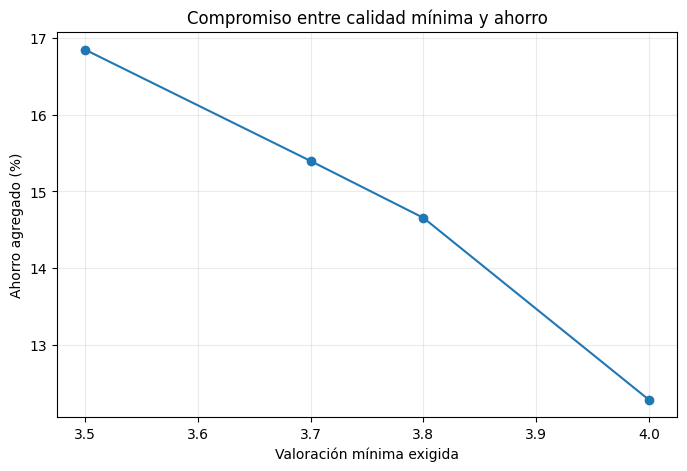

In [34]:
sensibilidad_global = (
    resultados_validacion[resultados_validacion["Factible"]]
    .groupby("UmbralValoracion")
    .agg(
        CosteReferenciaTotal=("CosteReferenciaForecast", "sum"),
        CosteIndiceTotal=("CosteIndiceBase", "sum"),
        CosteOptimizadoTotal=("CosteOptimizado", "sum"),
        Escenarios=("Factible", "size")
    )
    .reset_index()
)

sensibilidad_global["AhorroTotalVsReferencia"] = (
    sensibilidad_global["CosteReferenciaTotal"]
    - sensibilidad_global["CosteOptimizadoTotal"]
)
sensibilidad_global["AhorroPctVsReferencia"] = (
    100 * sensibilidad_global["AhorroTotalVsReferencia"]
    / sensibilidad_global["CosteReferenciaTotal"]
)
sensibilidad_global["AhorroTotalVsIndice"] = (
    sensibilidad_global["CosteIndiceTotal"]
    - sensibilidad_global["CosteOptimizadoTotal"]
)

display(sensibilidad_global.round(3))

plt.figure(figsize=(8, 5))
plt.plot(
    sensibilidad_global["UmbralValoracion"],
    sensibilidad_global["AhorroPctVsReferencia"],
    marker="o"
)
plt.xlabel("Valoración mínima exigida")
plt.ylabel("Ahorro agregado (%)")
plt.title("Compromiso entre calidad mínima y ahorro")
plt.grid(True, alpha=0.25)
plt.show()

## 14. Conclusiones

In [35]:
todos = resultados_validacion.copy()
factibles = todos[todos["Factible"]].copy()

print("CONCLUSIONES")
print("=" * 75)
print(f"Series objetivo del forecast: {len(series_objetivo):,}")
print(f"Series con demanda prevista > 0 y demanda operativa >= 1: {len(series_objetivo):,}")
print(f"Tratamientos objetivo: {forecast_completo['CODIGO_TRATAMIENTO'].nunique():,}")
print(f"Municipios objetivo: {forecast_completo['CODIGO_MUNICIPIO'].nunique():,}")
print(f"Demanda prevista total (4 semanas, 50 series): {demanda_total_forecast:,.2f}")
print("Capacidad: dato real CAPACIDAD_ANUAL, convertido a horizonte de 4 semanas (4/52).")
print(f"Umbrales analizados: {UMBRALES_VALORACION}")
print(f"Umbral utilizado como escenario principal: {UMBRAL_SELECCIONADO:.1f}")

seleccion = factibles[
    np.isclose(factibles["UmbralValoracion"], UMBRAL_SELECCIONADO)
].copy()

if seleccion.empty:
    print("No hay escenarios factibles para el umbral seleccionado.")
else:
    coste_ref = seleccion["CosteReferenciaForecast"].sum()
    coste_ind = seleccion["CosteIndiceBase"].sum()
    coste_opt = seleccion["CosteOptimizado"].sum()

    print(f"Escenarios factibles en el umbral seleccionado: {len(seleccion):,}")
    print(f"Escenarios no factibles: {len(resultados_validacion) // len(UMBRALES_VALORACION) - len(seleccion):,}")
    print(f"Ahorro total vs referencia: {coste_ref - coste_opt:,.2f} €")
    print(f"Ahorro porcentual agregado vs referencia: {100*(coste_ref-coste_opt)/coste_ref:.2f}%")
    print(f"Ahorro adicional vs índice: {coste_ind - coste_opt:,.2f} €")
    print(f"Ahorro porcentual adicional vs índice: {100*(coste_ind-coste_opt)/coste_ind:.2f}%")
    mejor = seleccion.sort_values("AhorroVsReferencia", ascending=False).iloc[0]
    print(f"Mayor ahorro individual: {mejor['AhorroVsReferencia']:,.2f} €")
    print(f"Mayor ahorro porcentual individual: {mejor['AhorroPctVsReferencia']:.2f}%")

print()
print("INTERPRETACIÓN")
print("- El forecast define la demanda futura sobre la que se realiza la optimización.")
print("- Los cuatro umbrales son escenarios alternativos; el usuario selecciona cuál utilizar como escenario principal.")
print("- El coste de referencia aplica el coste medio histórico a la demanda prevista.")
print("- La optimización directa busca el menor coste compatible con el umbral de valoración seleccionado.")
print("- El Ranking operativo aprovecha los datos de la optimización para recomendar los proveedores de manera flexible en la web."
      "  Asimismo, se adaptará a la asignación que se haga para acercarse lo más posible al resultado óptimo.")
print("- El ahorro agregado se calcula sobre el conjunto de escenarios factibles y pondera naturalmente por su coste previsto.")
print("- La capacidad utilizada procede directamente de CAPACIDAD_ANUAL para cada combinación proveedor–tratamiento–municipio y se convierte al horizonte de cuatro semanas.")

CONCLUSIONES
Series objetivo del forecast: 45
Series con demanda prevista > 0 y demanda operativa >= 1: 45
Tratamientos objetivo: 40
Municipios objetivo: 5
Demanda prevista total (4 semanas, 50 series): 290.20
Capacidad: dato real CAPACIDAD_ANUAL, convertido a horizonte de 4 semanas (4/52).
Umbrales analizados: [3.5, 3.7, 3.8, 4.0]
Umbral utilizado como escenario principal: 3.7
Escenarios factibles en el umbral seleccionado: 43
Escenarios no factibles: 2
Ahorro total vs referencia: 1,677.09 €
Ahorro porcentual agregado vs referencia: 15.40%
Ahorro adicional vs índice: 279.13 €
Ahorro porcentual adicional vs índice: 2.94%
Mayor ahorro individual: 457.19 €
Mayor ahorro porcentual individual: 59.04%

INTERPRETACIÓN
- El forecast define la demanda futura sobre la que se realiza la optimización.
- Los cuatro umbrales son escenarios alternativos; el usuario selecciona cuál utilizar como escenario principal.
- El coste de referencia aplica el coste medio histórico a la demanda prevista.
- La 

## Nota metodológica

El programa **no elige automáticamente el umbral que maximiza el ahorro**.

La tabla de sensibilidad conserva los cuatro escenarios para estudiar el compromiso entre calidad y coste. El selector `Valoración mínima` determina cuál de ellos se utiliza como escenario principal para:

- el ranking;
- el ahorro agregado;
- el diagnóstico de inviabilidad;
- las conclusiones.

Esto evita que el modelo confunda una **decisión de política de calidad** con una consecuencia automática de la optimización económica.

### Capacidad real

En esta versión, `CAPACIDAD_ANUAL` se interpreta como la capacidad anual de cada combinación **proveedor–tratamiento–municipio**, ya que su valor es diferente para cada combinación aunque lo asuma el mismo proveedor. La capacidad se transforma al horizonte del forecast mediante `CAPACIDAD_ANUAL × 4/52`.